array_out:  [[0.43299913 0.43391487 0.43483037 ... 0.43025205 0.4311678  0.43208343]
 [0.68520683 0.6861111  0.6870146  ... 0.68249106 0.68339664 0.68430185]
 [0.621161   0.62206066 0.6229603  ... 0.61846185 0.6193616  0.6202613 ]
 ...
 [0.4496343  0.44876558 0.44795617 ... 0.45256335 0.45153713 0.45055932]
 [0.538886   0.5397486  0.54061055 ... 0.53629506 0.5371593  0.53802294]
 [0.3777889  0.3786104  0.37943816 ... 0.37537616 0.37617004 0.37697494]]


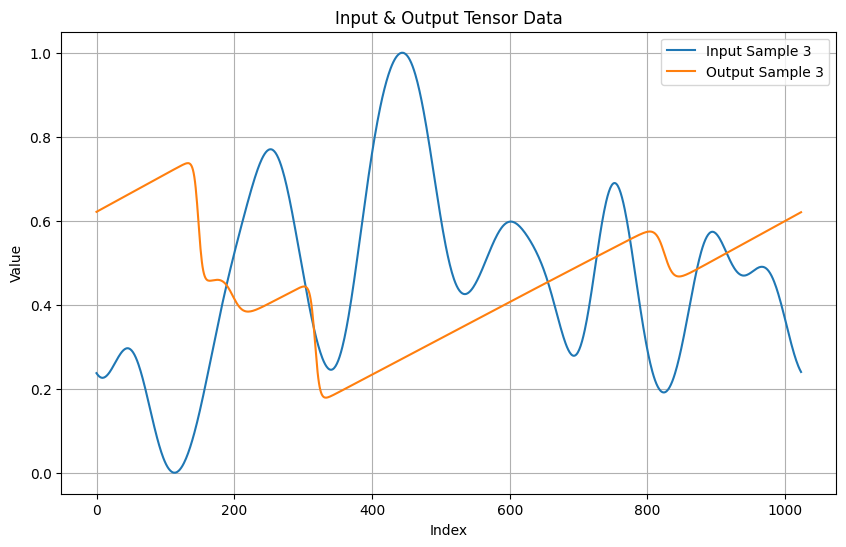

In [5]:
import torch
import matplotlib.pyplot as plt

def plot_input_output(N=20, nu=0.0005, seed=1000045, i_in=4, i_out=4):
    """
    读取 .pt 文件并绘制输入/输出样本曲线
    
    参数:
        N (int): N值
        nu (float): 粘性系数
        seed (int): 随机种子
        i_in (int): 输入样本编号（从0开始）
        i_out (int): 输出样本编号（从0开始）
    """
    # 文件路径
    file_path_in = f"inputs_dim1d_nx1024_N{N}_solver=exponax_kernel=gaussian_correlation_length0.03_bcperiodic_nu{nu}_t1.0_seed{seed}.pt"
    file_path_out = f"outputs_dim1d_nx1024_N{N}_solver=exponax_kernel=gaussian_correlation_length0.03_bcperiodic_nu{nu}_t1.0_seed{seed}.pt"

    # 读取
    tensor_in = torch.load(file_path_in)
    tensor_out = torch.load(file_path_out)

    # 转 numpy
    if tensor_in.is_cuda:
        tensor_in = tensor_in.cpu()
    if tensor_out.is_cuda:
        tensor_out = tensor_out.cpu()

    array_in = tensor_in.numpy()
    array_out = tensor_out.numpy()
    print("array_out: ", array_out)

    # 画图
    plt.figure(figsize=(10, 6))
    plt.plot(array_in[i_in], label=f'Input Sample {i_in+1}')
    plt.plot(array_out[i_out], label=f'Output Sample {i_out+1}')
    plt.title("Input & Output Tensor Data")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()

# 调用示例
i = 2
plot_input_output(N=20, nu=0.0005, seed=1000045, i_in=i, i_out=i)
